# Taller — Riesgo de crédito
Gerencia de riesgos financieros 2026-2 · Actividad en clase (septiembre 2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

loan_data = pd.read_csv("https://raw.githubusercontent.com/salas317/Data/main/GRF/loan_data_ch1.csv", index_col=0)
loan_data.head()

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age
1,0,5000,10.65,B,10.0,RENT,24000.0,33
2,0,2400,NaN,C,25.0,RENT,12252.0,31
3,0,10000,13.49,C,13.0,RENT,49200.0,24
4,0,5000,NaN,A,3.0,RENT,36000.0,39
5,0,3000,NaN,E,9.0,RENT,48000.0,24


## Parte 1
### 1. `value_counts` del estado del préstamo (conteo y proporción)

In [2]:
print(loan_data["loan_status"].value_counts())
print(loan_data["loan_status"].value_counts(normalize=True).round(3))

loan_status
0    25865
1     3227
Name: count, dtype: int64
loan_status
0    0.889
1    0.111
Name: proportion, dtype: float64


`loan_status = 1` es *default* (impago) y `0` es no default. La base está muy desbalanceada: alrededor del 11% de los préstamos están en default.

### 2. `crosstab` de `grade` (filas) vs `loan_status` (columnas)

In [3]:
pd.crosstab(index=loan_data["grade"], columns=loan_data["loan_status"], margins=True)

loan_status,0,1,All
grade,,,
A,9084,565,9649
B,8344,985,9329
C,4904,844,5748
D,2651,580,3231
E,692,176,868
F,155,56,211
G,35,21,56
All,25865,3227,29092


In [4]:
pd.crosstab(index=loan_data["grade"], columns=loan_data["loan_status"], normalize="index").round(3)

loan_status,0,1
grade,,
A,0.941,0.059
B,0.894,0.106
C,0.853,0.147
D,0.820,0.180
E,0.797,0.203
F,0.735,0.265
G,0.625,0.375


La proporción de default crece de forma monótona al pasar de la calificación A (mejor) a G (peor): la calificación sí discrimina el riesgo.

## Parte 2
### 3. Histograma de la cantidad prestada

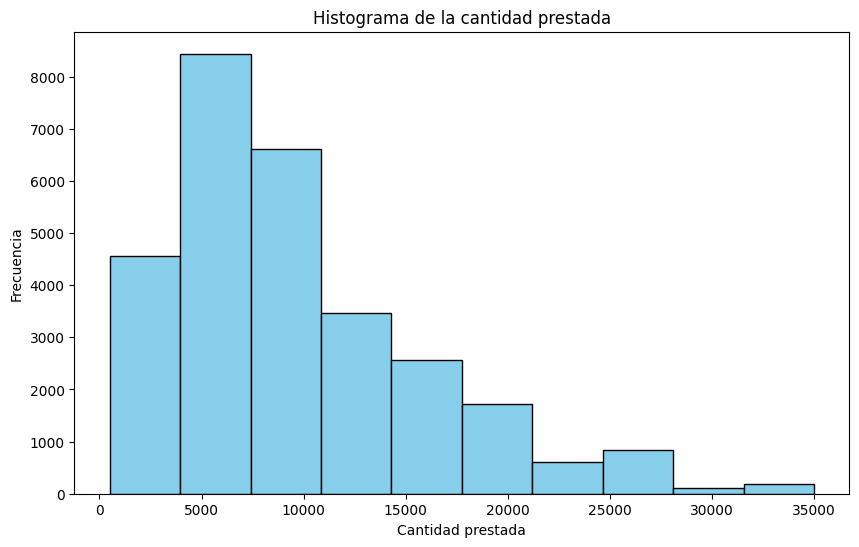

In [5]:
plt.figure(figsize=(10,6))
plt.hist(loan_data["loan_amnt"], color="skyblue", edgecolor="black")
plt.title("Histograma de la cantidad prestada"); plt.xlabel("Cantidad prestada"); plt.ylabel("Frecuencia")
plt.show()

### 4. Información de los cortes del histograma

In [6]:
n, bins, _ = plt.hist(loan_data["loan_amnt"], color="skyblue", edgecolor="black"); plt.close()
for i in range(len(n)):
    print(f"Corte {i+1}: [{bins[i]:,.0f}, {bins[i+1]:,.0f}) -> {int(n[i])} observaciones")

Corte 1: [500, 3,950) -> 4558 observaciones
Corte 2: [3,950, 7,400) -> 8437 observaciones
Corte 3: [7,400, 10,850) -> 6603 observaciones
Corte 4: [10,850, 14,300) -> 3471 observaciones
Corte 5: [14,300, 17,750) -> 2566 observaciones
Corte 6: [17,750, 21,200) -> 1711 observaciones
Corte 7: [21,200, 24,650) -> 614 observaciones
Corte 8: [24,650, 28,100) -> 832 observaciones
Corte 9: [28,100, 31,550) -> 112 observaciones
Corte 10: [31,550, 35,000) -> 188 observaciones


### 5. 200 cortes, eje x y título

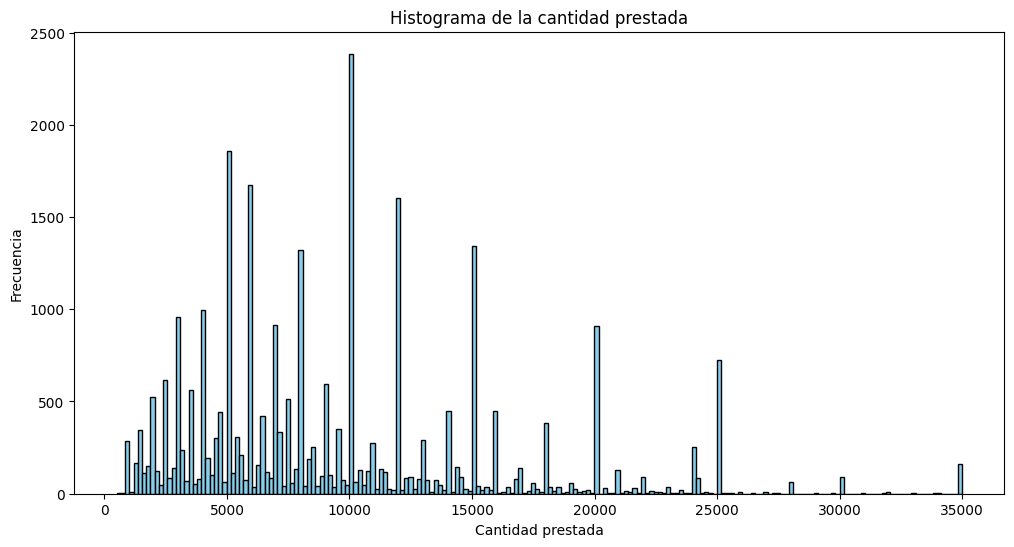

In [7]:
plt.figure(figsize=(12,6))
plt.hist(loan_data["loan_amnt"], bins=200, color="skyblue", edgecolor="black")
plt.title("Histograma de la cantidad prestada"); plt.xlabel("Cantidad prestada"); plt.ylabel("Frecuencia")
plt.show()

**¿Por qué ocurren los picos donde ocurren?** Con más cortes aparecen picos regulares en montos “redondos” (10.000, 5.000, 6.000, 12.000, 15.000, 8.000…; el más frecuente es 10.000 con 2.372 préstamos). Los préstamos no se piden en montos continuos: tanto los solicitantes como la entidad tienden a pedir y aprobar cifras redondas, por lo que la cantidad prestada se concentra en esos valores y no se reparte de forma suave.

### 6. Diagrama de dispersión de la edad

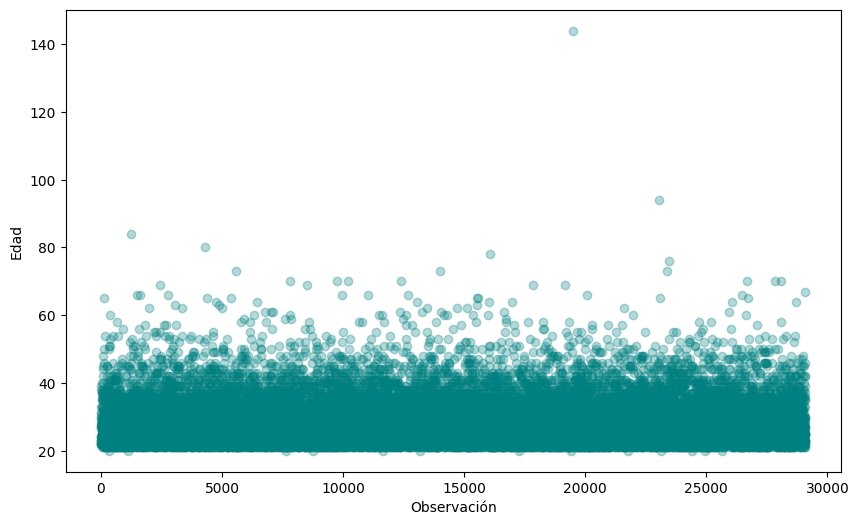

Edad máxima: 144


In [8]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(loan_data)), loan_data["age"], color="teal", alpha=0.3)
plt.xlabel("Observación"); plt.ylabel("Edad"); plt.show()
print("Edad máxima:", loan_data["age"].max())

### 7. Eliminar la observación de la persona con edad imposible
El enunciado habla de 122 años; en esta versión de la base la edad máxima es 144. Es el mismo caso (un error de captura), así que se elimina esa observación atípica (edad > 100).

In [9]:
print(loan_data[loan_data["age"] > 100])
new_data = loan_data[loan_data["age"] <= 100]
print(loan_data.shape, new_data.shape)

       loan_status  loan_amnt  int_rate grade  emp_length home_ownership  \
19486            0       5000     12.73     C        12.0       MORTGAGE   

       annual_inc  age  
19486   6000000.0  144  
(29092, 8) (29091, 8)


### 8. Edad vs ingreso anual (`new_data`)

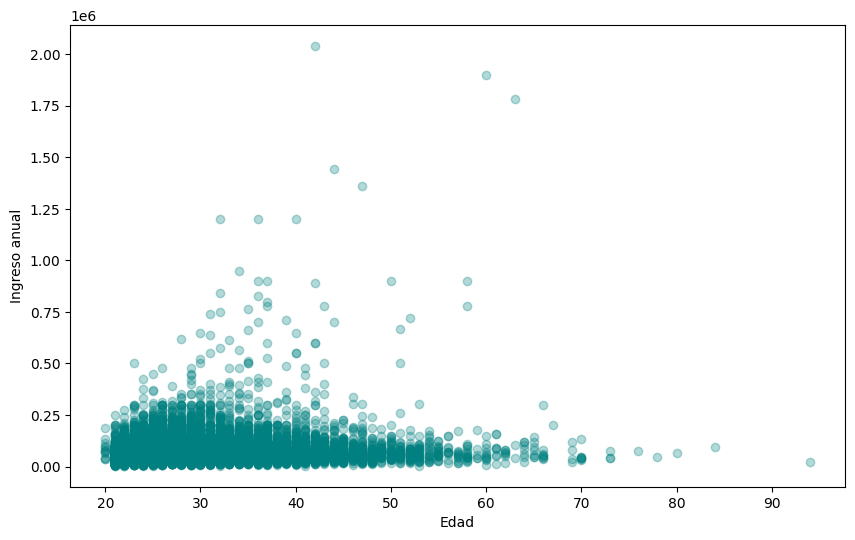

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(new_data["age"], new_data["annual_inc"], color="teal", alpha=0.3)
plt.xlabel("Edad"); plt.ylabel("Ingreso anual"); plt.show()

## Parte 3
### 9. Valores omitidos en la tasa de interés

In [11]:
print(loan_data["int_rate"].isna().sum())
loan_data.isna().sum()

2776


loan_status          0
loan_amnt            0
int_rate          2776
grade                0
emp_length         809
home_ownership       0
annual_inc           0
age                  0
dtype: int64

### 10. `loan_data_delrow_na`: eliminar registros con tasa omitida

In [12]:
loan_data_delrow_na = loan_data.dropna(subset=["int_rate"])
loan_data_delrow_na.shape

(26316, 8)

### 11. `loan_data_replace`: reemplazar con la mediana

In [13]:
loan_data_replace = loan_data.copy()
mediana = loan_data_replace["int_rate"].median()
loan_data_replace["int_rate"] = loan_data_replace["int_rate"].fillna(mediana)
print("Mediana:", mediana)

Mediana: 10.99


### 12. Verificación de que no quedan omitidos

In [14]:
print(loan_data_delrow_na["int_rate"].isna().sum(), loan_data_replace["int_rate"].isna().sum())

0 0


### 13. Variable `ir_cat`

In [15]:
cortes = [0, 8, 11, 13.5, np.inf]
etiquetas = ["0-8", "8-11", "11-13.5", "13.5+"]
loan_data["ir_cat"] = pd.cut(loan_data["int_rate"], bins=cortes, labels=etiquetas, right=False)
loan_data["ir_cat"] = loan_data["ir_cat"].cat.add_categories("missing")
loan_data.loc[loan_data["int_rate"].isna(), "ir_cat"] = "missing"
loan_data["ir_cat"].value_counts(sort=False)

ir_cat
0-8        6956
8-11       6404
11-13.5    6954
13.5+      6002
missing    2776
Name: count, dtype: int64

### 14. Gráfico de `ir_cat`

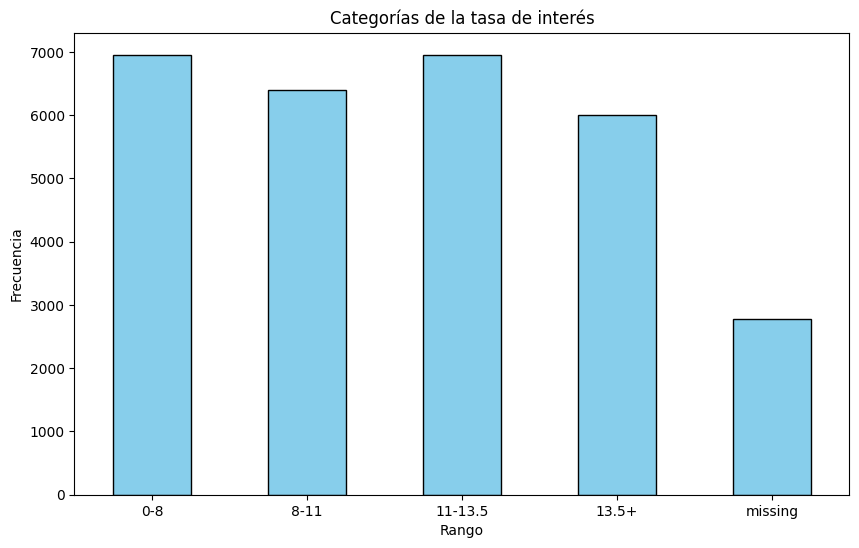

In [16]:
plt.figure(figsize=(10,6))
loan_data["ir_cat"].value_counts(sort=False).plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Categorías de la tasa de interés"); plt.xlabel("Rango"); plt.ylabel("Frecuencia"); plt.xticks(rotation=0)
plt.show()

## Parte 4
### 15. Entrenamiento (4/5) y prueba (1/5), semilla 567

In [17]:
training_set, test_set = train_test_split(loan_data, train_size=4/5, random_state=567)
print(training_set.shape, test_set.shape)

(23273, 9) (5819, 9)


### 16. Predicciones simuladas `model_pred`

In [18]:
np.random.seed(42)
model_pred = np.random.choice([0, 1], size=test_set.shape[0], p=[0.8, 0.2])
pd.Series(model_pred).value_counts()

0    4656
1    1163
Name: count, dtype: int64

### 17. Matriz de confusión

In [19]:
pd.crosstab(index=test_set["loan_status"], columns=model_pred, rownames=["Real"], colnames=["Predicho"])

Predicho,0,1
Real,,
0,4145,1021
1,511,142


In [20]:
tn, fp, fn, tp = confusion_matrix(test_set["loan_status"], model_pred).ravel()
print(tn, fp, fn, tp)

4145 1021 511 142


### 18. Precisión, sensibilidad y especificidad

In [21]:
precision = (tp + tn) / (tp + tn + fp + fn)
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)
print(f"Precisión (accuracy): {precision:.2%}")
print(f"Sensibilidad:         {sensibilidad:.2%}")
print(f"Especificidad:        {especificidad:.2%}")

Precisión (accuracy): 73.67%
Sensibilidad:         21.75%
Especificidad:        80.24%


Como `model_pred` es aleatorio (independiente de la realidad), sensibilidad ≈ 20% y especificidad ≈ 80%: el “modelo” no tiene poder predictivo; detecta tantos defaults como los que acertaría al azar.